### Install segment_anything package

In [ ]:
!pip install git+https://github.com/facebookresearch/segment-anything.git

In [1]:
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from skimage.measure import label, regionprops, find_contours

### Download the SAM checkpoint
https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

In [ ]:
%%time
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"
CHECKPOINT_PATH = "/raid/ml/root/sam_vit_h_4b8939.pth"
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device=DEVICE)

In [16]:
mask_generator = SamAutomaticMaskGenerator(sam)

In [17]:
%%time

IMAGE_PATH = '/raid/ml/root/reg_images_full/Train/A2miww5mfx.png'
image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
result = mask_generator.generate(image_rgb)

CPU times: user 2.77 s, sys: 115 ms, total: 2.88 s
Wall time: 2.88 s


In [7]:
len(result)

40

In [6]:
result

[{'segmentation': array([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [ True,  True,  True, ..., False, False, False],
         ...,
         [False, False, False, ...,  True,  True,  True],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]),
  'area': 214761,
  'bbox': [0, 0, 868, 250],
  'predicted_iou': 1.0482748746871948,
  'point_coords': [[393.765625, 74.8125]],
  'stability_score': 0.9871684908866882,
  'crop_box': [0, 0, 869, 252]},
 {'segmentation': array([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]),
  'area': 99,
  'bbox': [52, 78, 15, 6

In [20]:
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

def draw_mask_contours(image_cv, masks: list[np.ndarray]):
    """
    Draw contours of masks on an image and display it.
    
    :param image: PIL Image
    :param masks: List of numpy boolean arrays representing masks
    """
    if image_cv.shape[-1] == 4:
        image_cv = cv2.cvtColor(image_cv, cv2.COLOR_RGBA2RGB)
    
    # Define contour color and thickness
    contour_color = (0, 255, 0)  # Green
    thickness = 1
    
    # Draw contours for each mask
    for mask in masks:
        contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(image_cv, contours, -1, contour_color, thickness)
    
    # Display the image
    plt.figure(figsize=(20, 16))
    plt.imshow(image_cv)
    plt.axis("off")
    plt.show()

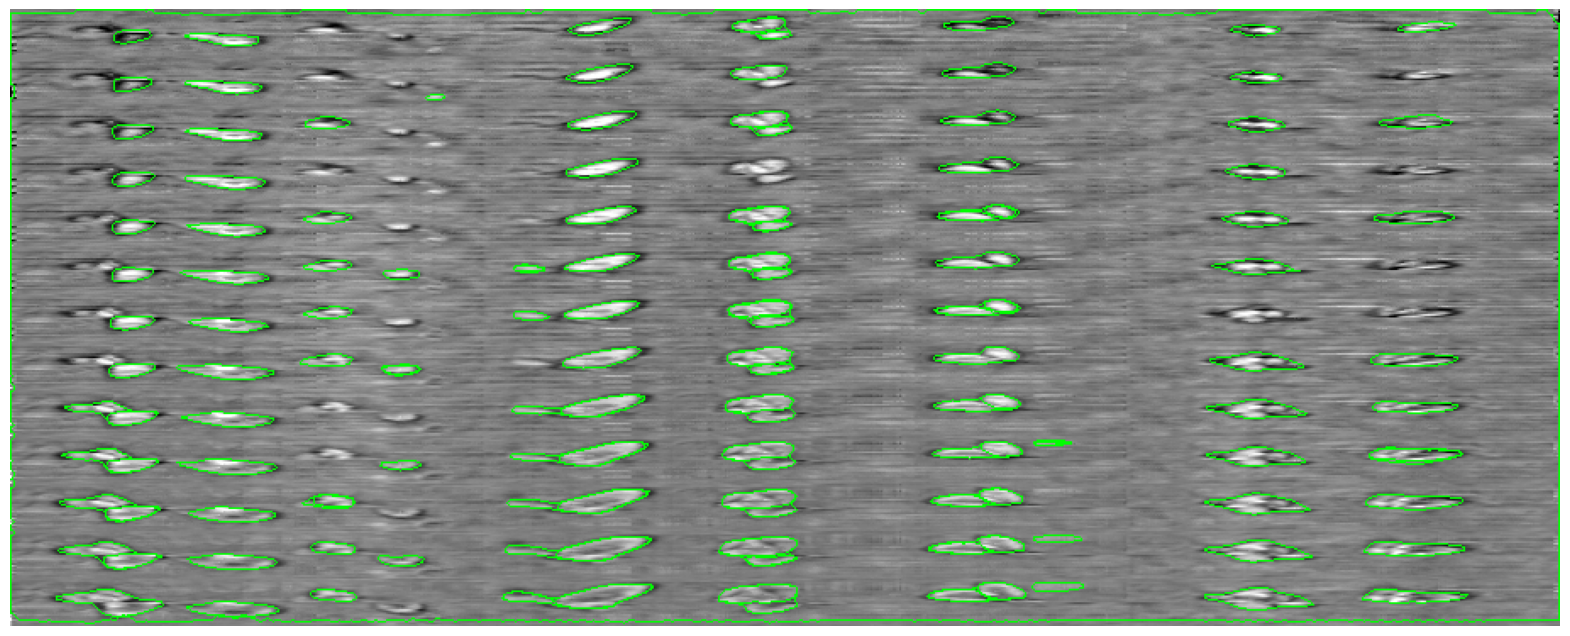

In [22]:
draw_mask_contours(image_rgb, [r['segmentation'] for r in result])